In [1]:
%run stochastic_lite.ipynb

In [2]:
import gwpy.timeseries

In [3]:
tstart = 1184098680+88 # start time of job, plus 88 seconds so start time aligns with stochastic.m run here: https://git.ligo.org/stochastic-public/stochastic/-/blob/O2StochIso/example_output_for_comparison.txt
tend = 1184101352
dur = 2672

deltaF=1./32
segmentDuration=192

In [4]:
data_H1=gwpy.timeseries.TimeSeries.fetch_open_data('H1',tstart,tend)
data_L1=gwpy.timeseries.TimeSeries.fetch_open_data('L1',tstart,tend)

/Users/andrewmatas/opt/anaconda3/envs/igwn-py37/lib/python3.7/site-packages/gwpy/types/series.py:926: UserWarning: TimeSeries.crop given end larger than current end, crop will end when the Series actually ends.
  % type(self).__name__)
/Users/andrewmatas/opt/anaconda3/envs/igwn-py37/lib/python3.7/site-packages/gwpy/types/series.py:917: UserWarning: TimeSeries.crop given start smaller than current start, crop will begin when the Series actually starts.
  % type(self).__name__)


In [5]:
t,h = data_H1.times.value,data_H1.value
fs = int(1/data_H1.dt.value)
nan_filter=np.isnan(h)
h[nan_filter]=0
d1=TimeSeries(t,h)

In [6]:
t,h = data_L1.times.value,data_L1.value
fs = int(1/data_L1.dt.value)
nan_filter=np.isnan(h)
h[nan_filter]=0
d2=TimeSeries(t,h)

In [7]:
nperseg=int(d1.Fs/deltaF)
freqs,P1_test = welch_psd(d1.data,nperseg=nperseg,window='Hann',fs=d1.Fs)

In [8]:
nperseg=int(d2.Fs/deltaF)
freqs,P2_test = welch_psd(d2.data,nperseg=nperseg,window='Hann',fs=d2.Fs)

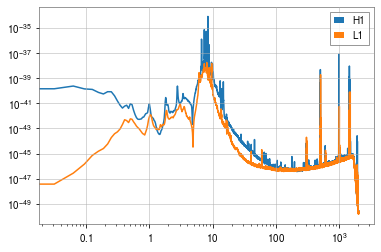

In [9]:
plt.loglog(freqs,P1_test,label='H1')
plt.loglog(freqs,P2_test,label='L1')
plt.legend()

In [10]:
Ys,sigs,Y_fs,var_fs,segmentStartTimes,freqs=stochastic(d1,
                                                       d2,
                                                       segmentDuration,
                                                       deltaF,
                                                       verbose=False,
                                                       doOverlap=True,
                                                       alpha=0,
                                                       fref=25,
                                                       orf_file='orfs/ORF_HL.dat')


/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:106: RuntimeWarning: divide by zero encountered in power
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:114: ComplexWarning: Casting complex values to real discards the imaginary part
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:115: ComplexWarning: Casting complex values to real discards the imaginary part


In [11]:
# notches
freqsToRemove = np.array([60.0,120.0,180.0,240.0,300.0,360.0,420.0,480.0,540.0,600.0,660.0,720.0,780.0,840.0,900.0,960.0,1020.0,1080.0,1140.0,1200.0,1260.0,1320.0,1380.0,1440.0,1500.0,1560.0,1620.0,1680.0,1740.0,1800.0,1860.0,1920.0,1980.0,2040.0,2100.0,2160.0,2220.0,2280.0,2340.0,2400.0,500.0,1000.0,1497.5,1250.0,35.90625,36.6875,37.1875,331.90625,1083.6875,22.6875,23.3125,23.90625,331.3125,1083.09375,15.6875,16.3125,16.90625,265.5625,848.96875,575.15625,108.84375,1392.375,52.8125,145.875,1220.5,190.625,763.84375,26.34375,31.4375,38.1875,12.4375,1991.09375,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,31.0,32.0,33.0,34.0,35.0,36.0,37.0,38.0,39.0,40.0,41.0,42.0,43.0,44.0,45.0,46.0,47.0,48.0,49.0,50.0,51.0,52.0,53.0,54.0,55.0,56.0,57.0,58.0,59.0,60.0,61.0,62.0,63.0,64.0,65.0,66.0,67.0,68.0,69.0,70.0,71.0,72.0,73.0,74.0,75.0,76.0,77.0,78.0,79.0,80.0,81.0,82.0,83.0,84.0,85.0,86.0,87.0,88.0,89.0,90.0,91.0,92.0,93.0,94.0,95.0,96.0,97.0,98.0,99.0,100.0,101.0,102.0,103.0,104.0,105.0,106.0,107.0,108.0,109.0,110.0,111.0,112.0,113.0,114.0,115.0,116.0,117.0,118.0,119.0,120.0,121.0,122.0,123.0,124.0,125.0,126.0,127.0,128.0,129.0,130.0,131.0,132.0,133.0,134.0,135.0,136.0,137.0,138.0,139.0,140.0,141.0,142.0,143.0,144.0,145.0,146.0,147.0,148.0,149.0,150.0,151.0,152.0,153.0,154.0,155.0,156.0,157.0,158.0,159.0,160.0,161.0,162.0,163.0,164.0,165.0,166.0,167.0,168.0,169.0,170.0,171.0,172.0,173.0,174.0,175.0,176.0,177.0,178.0,179.0,180.0,181.0,182.0,183.0,184.0,185.0,186.0,187.0,188.0,189.0,190.0,191.0,192.0,193.0,194.0,195.0,196.0,197.0,198.0,199.0,200.0,201.0,202.0,203.0,204.0,205.0,206.0,207.0,208.0,209.0,210.0,211.0,212.0,213.0,214.0,215.0,216.0,217.0,218.0,219.0,220.0,221.0,222.0,223.0,224.0,225.0,226.0,227.0,228.0,229.0,230.0,231.0,232.0,233.0,234.0,235.0,236.0,237.0,238.0,239.0,240.0,241.0,242.0,243.0,244.0,245.0,246.0,247.0,248.0,249.0,250.0,251.0,252.0,253.0,254.0,255.0,256.0,257.0,258.0,259.0,260.0,261.0,262.0,263.0,264.0,265.0,266.0,267.0,268.0,269.0,270.0,271.0,272.0,273.0,274.0,275.0,276.0,277.0,278.0,279.0,280.0,281.0,282.0,283.0,284.0,285.0,286.0,287.0,288.0,289.0,290.0,291.0,292.0,293.0,294.0,295.0,296.0,297.0,298.0,299.0,300.0,301.0,302.0,303.0,304.0,305.0,306.0,307.0,308.0,309.0,310.0,311.0,312.0,313.0,314.0,315.0,316.0,317.0,318.0,319.0,320.0,321.0,322.0,323.0,324.0,325.0,326.0,327.0,328.0,329.0,330.0,331.0,332.0,333.0,334.0,335.0,336.0,337.0,338.0,339.0,340.0,341.0,342.0,343.0,344.0,345.0,346.0,347.0,348.0,349.0,350.0,351.0,352.0,353.0,354.0,355.0,356.0,357.0,358.0,359.0,360.0,361.0,362.0,363.0,364.0,365.0,366.0,367.0,368.0,369.0,370.0,371.0,372.0,373.0,374.0,375.0,376.0,377.0,378.0,379.0,380.0,381.0,382.0,383.0,384.0,385.0,386.0,387.0,388.0,389.0,390.0,391.0,392.0,393.0,394.0,395.0,396.0,397.0,398.0,399.0,400.0,401.0,402.0,403.0,404.0,405.0,406.0,407.0,408.0,409.0,410.0,411.0,412.0,413.0,414.0,415.0,416.0,417.0,418.0,419.0,420.0,421.0,422.0,423.0,424.0,425.0,426.0,427.0,428.0,429.0,430.0,431.0,432.0,433.0,434.0,435.0,436.0,437.0,438.0,439.0,440.0,441.0,442.0,443.0,444.0,445.0,446.0,447.0,448.0,449.0,450.0,451.0,452.0,453.0,454.0,455.0,456.0,457.0,458.0,459.0,460.0,461.0,462.0,463.0,464.0,465.0,466.0,467.0,468.0,469.0,470.0,471.0,472.0,473.0,474.0,475.0,476.0,477.0,478.0,479.0,480.0,481.0,482.0,483.0,484.0,485.0,486.0,487.0,488.0,489.0,490.0,491.0,492.0,493.0,494.0,495.0,496.0,497.0,498.0,499.0,500.0,501.0,502.0,503.0,504.0,505.0,506.0,507.0,508.0,509.0,510.0,511.0,512.0,513.0,514.0,515.0,516.0,517.0,518.0,519.0,520.0,521.0,522.0,523.0,524.0,525.0,526.0,527.0,528.0,529.0,530.0,531.0,532.0,533.0,534.0,535.0,536.0,537.0,538.0,539.0,540.0,541.0,542.0,543.0,544.0,545.0,546.0,547.0,548.0,549.0,550.0,551.0,552.0,553.0,554.0,555.0,556.0,557.0,558.0,559.0,560.0,561.0,562.0,563.0,564.0,565.0,566.0,567.0,568.0,569.0,570.0,571.0,572.0,573.0,574.0,575.0,576.0,577.0,578.0,579.0,580.0,581.0,582.0,583.0,584.0,585.0,586.0,587.0,588.0,589.0,590.0,591.0,592.0,593.0,594.0,595.0,596.0,597.0,598.0,599.0,600.0,601.0,602.0,603.0,604.0,605.0,606.0,607.0,608.0,609.0,610.0,611.0,612.0,613.0,614.0,615.0,616.0,617.0,618.0,619.0,620.0,621.0,622.0,623.0,624.0,625.0,626.0,627.0,628.0,629.0,630.0,631.0,632.0,633.0,634.0,635.0,636.0,637.0,638.0,639.0,640.0,641.0,642.0,643.0,644.0,645.0,646.0,647.0,648.0,649.0,650.0,651.0,652.0,653.0,654.0,655.0,656.0,657.0,658.0,659.0,660.0,661.0,662.0,663.0,664.0,665.0,666.0,667.0,668.0,669.0,670.0,671.0,672.0,673.0,674.0,675.0,676.0,677.0,678.0,679.0,680.0,681.0,682.0,683.0,684.0,685.0,686.0,687.0,688.0,689.0,690.0,691.0,692.0,693.0,694.0,695.0,696.0,697.0,698.0,699.0,700.0,701.0,702.0,703.0,704.0,705.0,706.0,707.0,708.0,709.0,710.0,711.0,712.0,713.0,714.0,715.0,716.0,717.0,718.0,719.0,720.0,721.0,722.0,723.0,724.0,725.0,726.0,727.0,728.0,729.0,730.0,731.0,732.0,733.0,734.0,735.0,736.0,737.0,738.0,739.0,740.0,741.0,742.0,743.0,744.0,745.0,746.0,747.0,748.0,749.0,750.0,751.0,752.0,753.0,754.0,755.0,756.0,757.0,758.0,759.0,760.0,761.0,762.0,763.0,764.0,765.0,766.0,767.0,768.0,769.0,770.0,771.0,772.0,773.0,774.0,775.0,776.0,777.0,778.0,779.0,780.0,781.0,782.0,783.0,784.0,785.0,786.0,787.0,788.0,789.0,790.0,791.0,792.0,793.0,794.0,795.0,796.0,797.0,798.0,799.0,800.0,801.0,802.0,803.0,804.0,805.0,806.0,807.0,808.0,809.0,810.0,811.0,812.0,813.0,814.0,815.0,816.0,817.0,818.0,819.0,820.0,821.0,822.0,823.0,824.0,825.0,826.0,827.0,828.0,829.0,830.0,831.0,832.0,833.0,834.0,835.0,836.0,837.0,838.0,839.0,840.0,841.0,842.0,843.0,844.0,845.0,846.0,847.0,848.0,849.0,850.0,851.0,852.0,853.0,854.0,855.0,856.0,857.0,858.0,859.0,860.0,861.0,862.0,863.0,864.0,865.0,866.0,867.0,868.0,869.0,870.0,871.0,872.0,873.0,874.0,875.0,876.0,877.0,878.0,879.0,880.0,881.0,882.0,883.0,884.0,885.0,886.0,887.0,888.0,889.0,890.0,891.0,892.0,893.0,894.0,895.0,896.0,897.0,898.0,899.0,900.0,901.0,902.0,903.0,904.0,905.0,906.0,907.0,908.0,909.0,910.0,911.0,912.0,913.0,914.0,915.0,916.0,917.0,918.0,919.0,920.0,921.0,922.0,923.0,924.0,925.0,926.0,927.0,928.0,929.0,930.0,931.0,932.0,933.0,934.0,935.0,936.0,937.0,938.0,939.0,940.0,941.0,942.0,943.0,944.0,945.0,946.0,947.0,948.0,949.0,950.0,951.0,952.0,953.0,954.0,955.0,956.0,957.0,958.0,959.0,960.0,961.0,962.0,963.0,964.0,965.0,966.0,967.0,968.0,969.0,970.0,971.0,972.0,973.0,974.0,975.0,976.0,977.0,978.0,979.0,980.0,981.0,982.0,983.0,984.0,985.0,986.0,987.0,988.0,989.0,990.0,991.0,992.0,993.0,994.0,995.0,996.0,997.0,998.0,999.0,1000.0,1001.0,1002.0,1003.0,1004.0,1005.0,1006.0,1007.0,1008.0,1009.0,1010.0,1011.0,1012.0,1013.0,1014.0,1015.0,1016.0,1017.0,1018.0,1019.0,1020.0,1021.0,1022.0,1023.0,1024.0,1025.0,1026.0,1027.0,1028.0,1029.0,1030.0,1031.0,1032.0,1033.0,1034.0,1035.0,1036.0,1037.0,1038.0,1039.0,1040.0,1041.0,1042.0,1043.0,1044.0,1045.0,1046.0,1047.0,1048.0,1049.0,1050.0,1051.0,1052.0,1053.0,1054.0,1055.0,1056.0,1057.0,1058.0,1059.0,1060.0,1061.0,1062.0,1063.0,1064.0,1065.0,1066.0,1067.0,1068.0,1069.0,1070.0,1071.0,1072.0,1073.0,1074.0,1075.0,1076.0,1077.0,1078.0,1079.0,1080.0,1081.0,1082.0,1083.0,1084.0,1085.0,1086.0,1087.0,1088.0,1089.0,1090.0,1091.0,1092.0,1093.0,1094.0,1095.0,1096.0,1097.0,1098.0,1099.0,1100.0,1101.0,1102.0,1103.0,1104.0,1105.0,1106.0,1107.0,1108.0,1109.0,1110.0,1111.0,1112.0,1113.0,1114.0,1115.0,1116.0,1117.0,1118.0,1119.0,1120.0,1121.0,1122.0,1123.0,1124.0,1125.0,1126.0,1127.0,1128.0,1129.0,1130.0,1131.0,1132.0,1133.0,1134.0,1135.0,1136.0,1137.0,1138.0,1139.0,1140.0,1141.0,1142.0,1143.0,1144.0,1145.0,1146.0,1147.0,1148.0,1149.0,1150.0,1151.0,1152.0,1153.0,1154.0,1155.0,1156.0,1157.0,1158.0,1159.0,1160.0,1161.0,1162.0,1163.0,1164.0,1165.0,1166.0,1167.0,1168.0,1169.0,1170.0,1171.0,1172.0,1173.0,1174.0,1175.0,1176.0,1177.0,1178.0,1179.0,1180.0,1181.0,1182.0,1183.0,1184.0,1185.0,1186.0,1187.0,1188.0,1189.0,1190.0,1191.0,1192.0,1193.0,1194.0,1195.0,1196.0,1197.0,1198.0,1199.0,1200.0,1201.0,1202.0,1203.0,1204.0,1205.0,1206.0,1207.0,1208.0,1209.0,1210.0,1211.0,1212.0,1213.0,1214.0,1215.0,1216.0,1217.0,1218.0,1219.0,1220.0,1221.0,1222.0,1223.0,1224.0,1225.0,1226.0,1227.0,1228.0,1229.0,1230.0,1231.0,1232.0,1233.0,1234.0,1235.0,1236.0,1237.0,1238.0,1239.0,1240.0,1241.0,1242.0,1243.0,1244.0,1245.0,1246.0,1247.0,1248.0,1249.0,1250.0,1251.0,1252.0,1253.0,1254.0,1255.0,1256.0,1257.0,1258.0,1259.0,1260.0,1261.0,1262.0,1263.0,1264.0,1265.0,1266.0,1267.0,1268.0,1269.0,1270.0,1271.0,1272.0,1273.0,1274.0,1275.0,1276.0,1277.0,1278.0,1279.0,1280.0,1281.0,1282.0,1283.0,1284.0,1285.0,1286.0,1287.0,1288.0,1289.0,1290.0,1291.0,1292.0,1293.0,1294.0,1295.0,1296.0,1297.0,1298.0,1299.0,1300.0,1301.0,1302.0,1303.0,1304.0,1305.0,1306.0,1307.0,1308.0,1309.0,1310.0,1311.0,1312.0,1313.0,1314.0,1315.0,1316.0,1317.0,1318.0,1319.0,1320.0,1321.0,1322.0,1323.0,1324.0,1325.0,1326.0,1327.0,1328.0,1329.0,1330.0,1331.0,1332.0,1333.0,1334.0,1335.0,1336.0,1337.0,1338.0,1339.0,1340.0,1341.0,1342.0,1343.0,1344.0,1345.0,1346.0,1347.0,1348.0,1349.0,1350.0,1351.0,1352.0,1353.0,1354.0,1355.0,1356.0,1357.0,1358.0,1359.0,1360.0,1361.0,1362.0,1363.0,1364.0,1365.0,1366.0,1367.0,1368.0,1369.0,1370.0,1371.0,1372.0,1373.0,1374.0,1375.0,1376.0,1377.0,1378.0,1379.0,1380.0,1381.0,1382.0,1383.0,1384.0,1385.0,1386.0,1387.0,1388.0,1389.0,1390.0,1391.0,1392.0,1393.0,1394.0,1395.0,1396.0,1397.0,1398.0,1399.0,1400.0,1401.0,1402.0,1403.0,1404.0,1405.0,1406.0,1407.0,1408.0,1409.0,1410.0,1411.0,1412.0,1413.0,1414.0,1415.0,1416.0,1417.0,1418.0,1419.0,1420.0,1421.0,1422.0,1423.0,1424.0,1425.0,1426.0,1427.0,1428.0,1429.0,1430.0,1431.0,1432.0,1433.0,1434.0,1435.0,1436.0,1437.0,1438.0,1439.0,1440.0,1441.0,1442.0,1443.0,1444.0,1445.0,1446.0,1447.0,1448.0,1449.0,1450.0,1451.0,1452.0,1453.0,1454.0,1455.0,1456.0,1457.0,1458.0,1459.0,1460.0,1461.0,1462.0,1463.0,1464.0,1465.0,1466.0,1467.0,1468.0,1469.0,1470.0,1471.0,1472.0,1473.0,1474.0,1475.0,1476.0,1477.0,1478.0,1479.0,1480.0,1481.0,1482.0,1483.0,1484.0,1485.0,1486.0,1487.0,1488.0,1489.0,1490.0,1491.0,1492.0,1493.0,1494.0,1495.0,1496.0,1497.0,1498.0,1499.0,1500.0,1501.0,1502.0,1503.0,1504.0,1505.0,1506.0,1507.0,1508.0,1509.0,1510.0,1511.0,1512.0,1513.0,1514.0,1515.0,1516.0,1517.0,1518.0,1519.0,1520.0,1521.0,1522.0,1523.0,1524.0,1525.0,1526.0,1527.0,1528.0,1529.0,1530.0,1531.0,1532.0,1533.0,1534.0,1535.0,1536.0,1537.0,1538.0,1539.0,1540.0,1541.0,1542.0,1543.0,1544.0,1545.0,1546.0,1547.0,1548.0,1549.0,1550.0,1551.0,1552.0,1553.0,1554.0,1555.0,1556.0,1557.0,1558.0,1559.0,1560.0,1561.0,1562.0,1563.0,1564.0,1565.0,1566.0,1567.0,1568.0,1569.0,1570.0,1571.0,1572.0,1573.0,1574.0,1575.0,1576.0,1577.0,1578.0,1579.0,1580.0,1581.0,1582.0,1583.0,1584.0,1585.0,1586.0,1587.0,1588.0,1589.0,1590.0,1591.0,1592.0,1593.0,1594.0,1595.0,1596.0,1597.0,1598.0,1599.0,1600.0,1601.0,1602.0,1603.0,1604.0,1605.0,1606.0,1607.0,1608.0,1609.0,1610.0,1611.0,1612.0,1613.0,1614.0,1615.0,1616.0,1617.0,1618.0,1619.0,1620.0,1621.0,1622.0,1623.0,1624.0,1625.0,1626.0,1627.0,1628.0,1629.0,1630.0,1631.0,1632.0,1633.0,1634.0,1635.0,1636.0,1637.0,1638.0,1639.0,1640.0,1641.0,1642.0,1643.0,1644.0,1645.0,1646.0,1647.0,1648.0,1649.0,1650.0,1651.0,1652.0,1653.0,1654.0,1655.0,1656.0,1657.0,1658.0,1659.0,1660.0,1661.0,1662.0,1663.0,1664.0,1665.0,1666.0,1667.0,1668.0,1669.0,1670.0,1671.0,1672.0,1673.0,1674.0,1675.0,1676.0,1677.0,1678.0,1679.0,1680.0,1681.0,1682.0,1683.0,1684.0,1685.0,1686.0,1687.0,1688.0,1689.0,1690.0,1691.0,1692.0,1693.0,1694.0,1695.0,1696.0,1697.0,1698.0,1699.0,1700.0,1701.0,1702.0,1703.0,1704.0,1705.0,1706.0,1707.0,1708.0,1709.0,1710.0,1711.0,1712.0,1713.0,1714.0,1715.0,1716.0,1717.0,1718.0,1719.0,1720.0,1721.0,1722.0,1723.0,1724.0,1725.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,31.0,32.0,33.0,34.0,35.0,36.0,37.0,38.0,39.0,40.0,41.0,42.0,56.0,64.0,72.0,100.0,304.875,763.8125,763.90625,1083.1875,1149.15625])
nBinsToRemove = np.array([7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,1281.0,2561.0,2721.0,3201.0,1.0,1.0,1.0,17.0,17.0,1.0,1.0,1.0,17.0,17.0,1.0,1.0,1.0,3.0,7.0,5.0,1.0,29.0,1.0,7.0,9.0,9.0,5.0,1.0,1.0,5.0,1.0,13.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,5.0,5.0,5.0])


notches=np.array([])
for fcenter,nbins in zip(freqsToRemove,nBinsToRemove):
    fmin = fcenter-0.5*(nbins-1)*deltaF
    fmax = fcenter+0.5*(nbins+1)*deltaF
    new_notches = np.arange(fmin,fmax,deltaF)
    notches=np.append(notches,new_notches)
notches=np.sort(np.unique(notches))


In [12]:
flow=20
fhigh=1726

f_filter=np.logical_and(freqs>=flow,freqs<=fhigh)

for fnotch in notches:
    f_filter=np.logical_and(f_filter,freqs!=fnotch)

f=freqs[f_filter]
Y_ft=Y_fs[f_filter,:]
var_ft=var_fs[f_filter,:]

Y_t = np.zeros(len(segmentStartTimes)-1)
var_t = np.zeros(len(segmentStartTimes)-1)

for ii in range(len(Y_t)):
    var_t[ii] = 1/np.sum(var_ft[:,ii]**(-1))
    Y_t[ii] = np.sum(Y_ft[:,ii] * var_t[ii]/var_ft[:,ii])
    
    print('segment = %u, start sec = %u, CC stat = %e, theor sigma = %e, SNR=%f'%(ii+3,
                                                                       segmentStartTimes[ii],
                                                                       np.real(Y_t[ii]) * segmentDuration,
                                                                       np.sqrt(var_t[ii]) * segmentDuration,
                                                                       np.real(Y_t[ii])/np.sqrt(var_t[ii])))


segment = 3, start sec = 1184098960, CC stat = 5.581732e-04, theor sigma = 7.282605e-04, SNR=0.766447
segment = 4, start sec = 1184099056, CC stat = 9.176867e-04, theor sigma = 7.034721e-04, SNR=1.304510
segment = 5, start sec = 1184099152, CC stat = -1.302768e-03, theor sigma = 7.076670e-04, SNR=-1.840933
segment = 6, start sec = 1184099248, CC stat = -6.492966e-04, theor sigma = 7.301185e-04, SNR=-0.889303
segment = 7, start sec = 1184099344, CC stat = 3.779046e-04, theor sigma = 7.120497e-04, SNR=0.530728
segment = 8, start sec = 1184099440, CC stat = -1.024705e-03, theor sigma = 7.092997e-04, SNR=-1.444671
segment = 9, start sec = 1184099536, CC stat = 5.166326e-04, theor sigma = 7.246562e-04, SNR=0.712935
segment = 10, start sec = 1184099632, CC stat = 1.052567e-04, theor sigma = 7.396940e-04, SNR=0.142298
segment = 11, start sec = 1184099728, CC stat = -7.251928e-04, theor sigma = 8.360809e-04, SNR=-0.867372
segment = 12, start sec = 1184099824, CC stat = -1.415267e-04, theor sig

In [27]:
our_sigs=np.sqrt(var_t) * segmentDuration
their_sigs=np.array([7.853712e-04,
                     7.571545e-04,
                     7.637193e-04,
                     7.912196e-04,
                     7.733409e-04,
                     7.672102e-04,
                     7.819537e-04,
                     7.995463e-04,
                     9.143164e-04,
                     9.105881e-04,
                     7.801733e-04,
                     7.739089e-04,
                     9.145471e-04,
                     9.262469e-04,
                     7.727491e-04,
                     7.698124e-04,
                     7.731911e-04,
                     7.815186e-04,
                     7.650608e-04,
                     7.692039e-04,
                     7.639890e-04])
print(our_sigs/their_sigs[:20])
print(their_sigs[:20]/our_sigs)

[0.92728186 0.9290998  0.92660611 0.92277606 0.92074489
 0.92451804 0.92672515 0.92514219 0.91443282 0.91640789
 0.92709836 0.92491819 0.91675059 0.9184424  0.93055274
 0.92663715 0.92397647 0.9276038  0.93526885 0.93371668]
[1.07842076 1.07631064 1.07920721 1.08368655 1.08607717
 1.08164466 1.07906859 1.08091492 1.09357405 1.09121714
 1.0786342  1.0811767  1.09080922 1.08879991 1.07463011
 1.07917106 1.08227865 1.07804647 1.06921128 1.07098869]


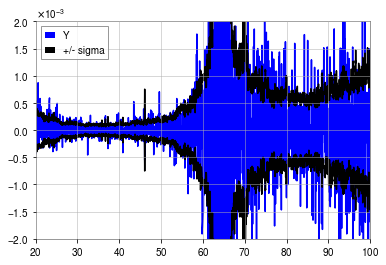

In [13]:
flow=20
fhigh=1726

f_filter=np.logical_and(freqs>=flow,freqs<=fhigh)

for fnotch in notches:
    f_filter=np.logical_and(f_filter,freqs!=fnotch)

plt.plot(freqs[f_filter],np.real(Y_fs[f_filter,0]),color='blue',label='Y')
plt.plot(freqs[f_filter],np.sqrt(var_fs[f_filter,0]),color='black',label='+/- sigma')
plt.plot(freqs[f_filter],-np.sqrt(var_fs[f_filter,0]),color='black')

plt.xlim(20,100)
plt.ylim(-2e-3,2e-3)

plt.legend()
